# EDA Breast Cancer Dataset

Цель этапа - провести предварительный анализ Breast Cancer Wisconsin Dataset и понять, какие методы предобработки будут наиболее важны для дальнейших экспериментов.

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from experiment_utils import load_breast_cancer_data, save_figure

sns.set_theme(style="whitegrid")


## Загрузка данных

Данные загружаются через встроенный датасет `load_breast_cancer`, целевая переменная сразу переводится в строковые метки `malignant` и `benign`.

In [2]:
df = load_breast_cancer_data()
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [3]:
df.shape


(569, 31)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## Проверка пропусков

Проверим, есть ли отсутствующие значения в признаках и целевой переменной.

In [6]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values.head(10)


mean radius               0
mean texture              0
mean perimeter            0
mean area                 0
mean smoothness           0
mean compactness          0
mean concavity            0
mean concave points       0
mean symmetry             0
mean fractal dimension    0
dtype: int64

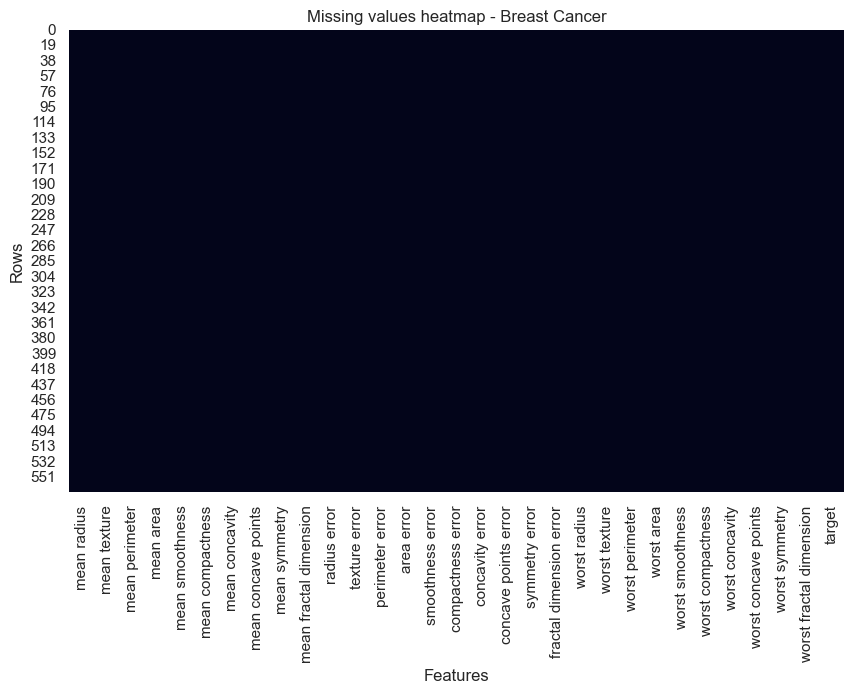

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing values heatmap - Breast Cancer")
plt.xlabel("Features")
plt.ylabel("Rows")
save_figure(FIGURES_DIR / "breast_cancer_missing_values.png")
plt.show()


## Распределение классов

Оценим баланс классов. В медицинской задаче положительным классом для F1-score считаем `malignant`.

In [8]:
class_counts = df["target"].value_counts()
class_counts


target
benign       357
malignant    212
Name: count, dtype: int64

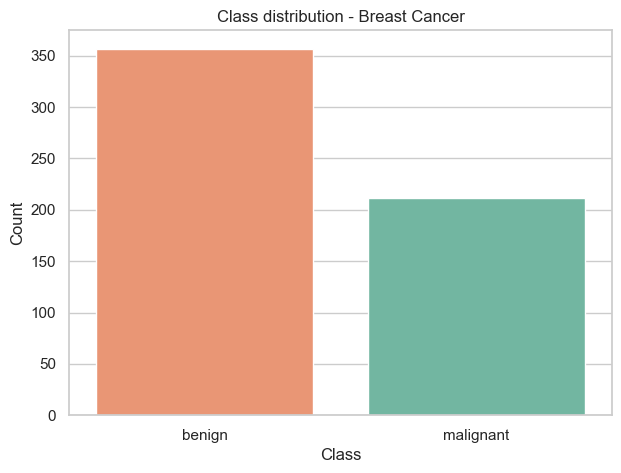

In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="target", order=["benign", "malignant"], hue="target", palette="Set2", legend=False)
plt.title("Class distribution - Breast Cancer")
plt.xlabel("Class")
plt.ylabel("Count")
save_figure(FIGURES_DIR / "breast_cancer_class_distribution.png")
plt.show()


## Распределения числовых признаков

Все признаки числовые. Посмотрим на несколько базовых характеристик опухоли.

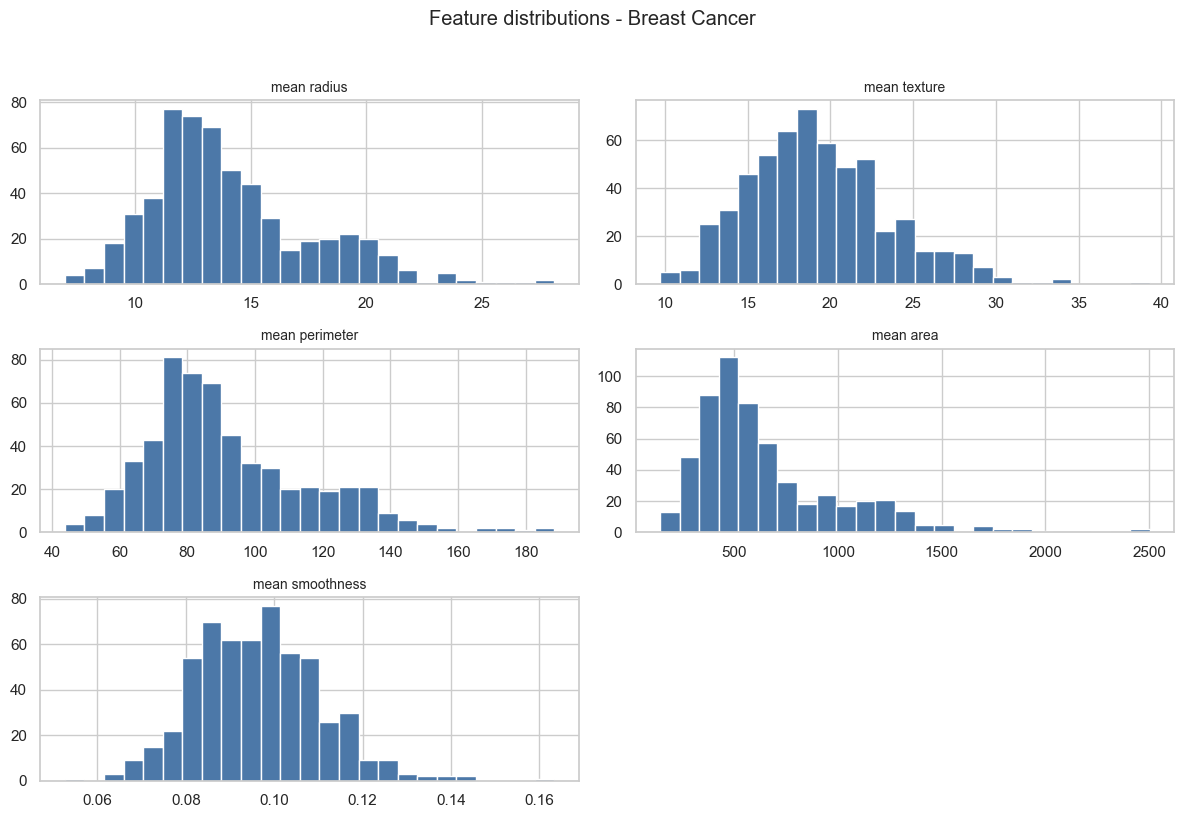

In [10]:
features = ["mean radius", "mean texture", "mean perimeter", "mean area", "mean smoothness"]
axes = df[features].hist(figsize=(12, 8), bins=25, color="#4C78A8", edgecolor="white")
for ax in axes.ravel():
    ax.set_title(ax.get_title(), fontsize=10)
plt.suptitle("Feature distributions - Breast Cancer", y=1.02)
plt.tight_layout()
save_figure(FIGURES_DIR / "breast_cancer_feature_distribution.png")
plt.show()


## Корреляции

Матрица корреляций помогает увидеть группы взаимосвязанных измерений, например радиус, периметр и площадь.

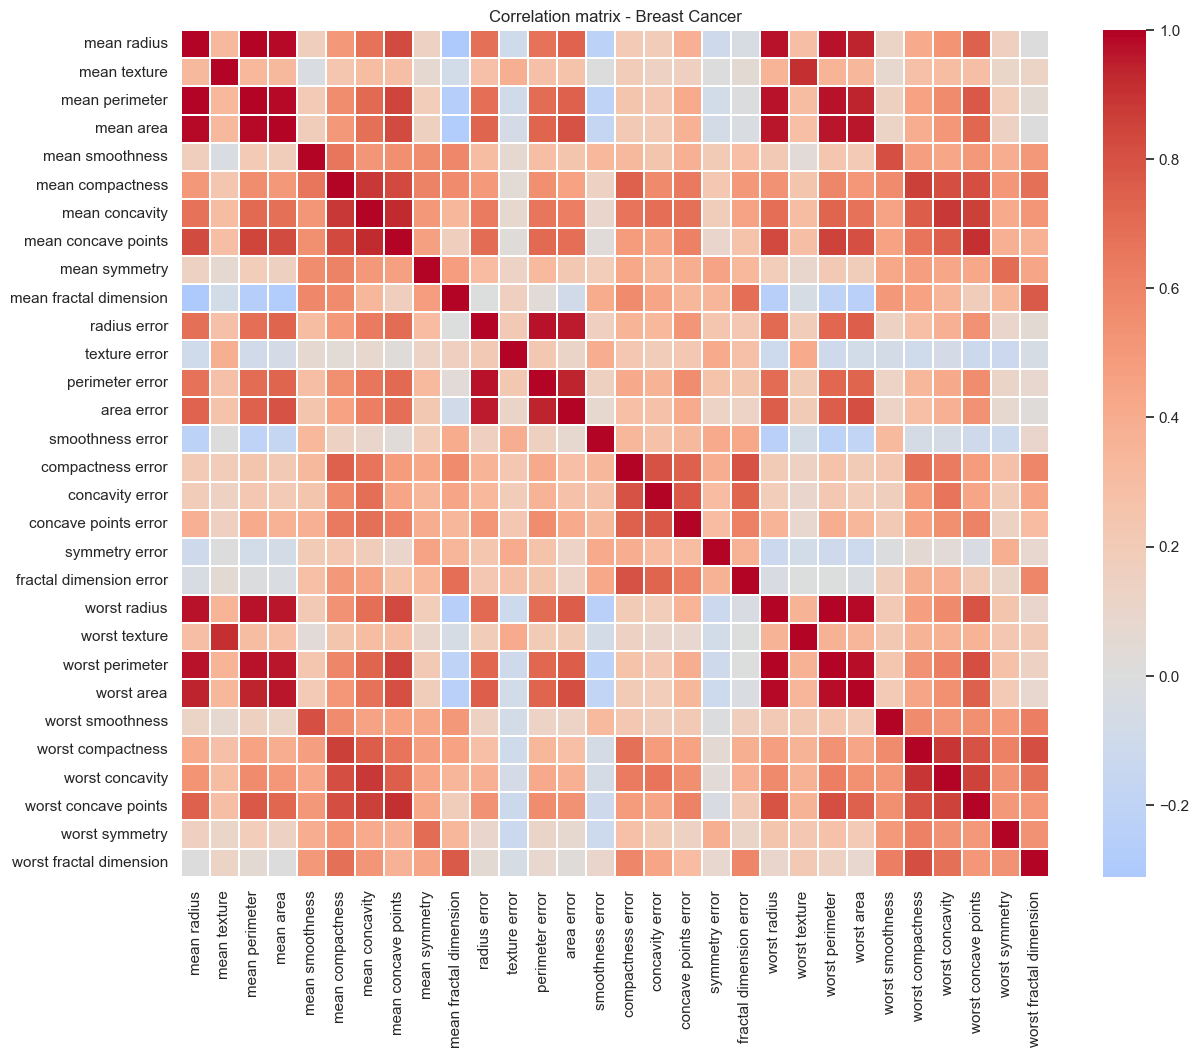

In [11]:
plt.figure(figsize=(14, 11))
corr = df.drop(columns="target").corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.1)
plt.title("Correlation matrix - Breast Cancer")
save_figure(FIGURES_DIR / "breast_cancer_correlation_matrix.png")
plt.show()


## Сравнение признаков по классам

Boxplot показывает, насколько значения важных признаков отличаются между доброкачественными и злокачественными опухолями.

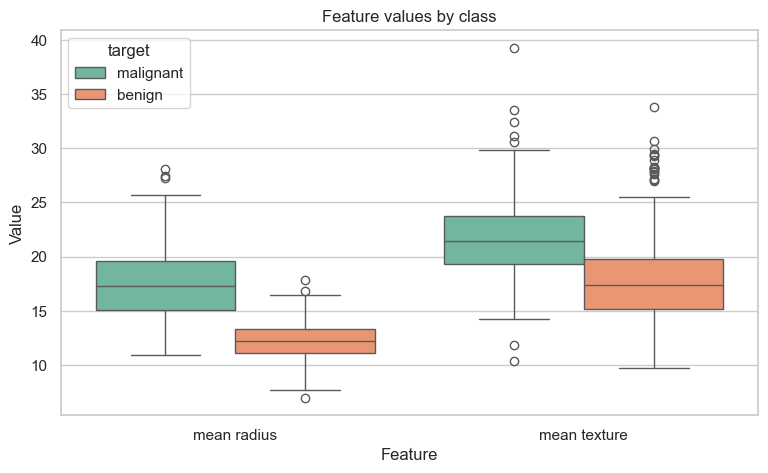

In [12]:
plot_df = df.melt(id_vars="target", value_vars=["mean radius", "mean texture"], var_name="feature", value_name="value")
plt.figure(figsize=(9, 5))
sns.boxplot(data=plot_df, x="feature", y="value", hue="target", palette="Set2")
plt.title("Feature values by class")
plt.xlabel("Feature")
plt.ylabel("Value")
save_figure(FIGURES_DIR / "breast_cancer_boxplot.png")
plt.show()


## Итоговый вывод

Датасет полностью числовой, пропуски отсутствуют, задача является бинарной классификацией. Основной интерес для Breast Cancer связан с масштабированием признаков и сравнением моделей, а эксперимент с импутацией нужен как контрольный: при отсутствии пропусков разные методы заполнения не должны существенно менять качество.